In [1]:
import matplotlib.pyplot as plt
plt.style.use('../styles/gcpeixoto-book.mplstyle')

(cap:sequencias)=
# Sequências

<div class="chapter-thumb">
    <div class="chapter-oa">
        <h2>Objetivos de aprendizagem</h2>
        <ul>
        <li>Explicar os fundamentos teóricos das sequências matemáticas, identificando suas leis de geração e progressões clássicas;</li>
	    <li>Descrever os comportamentos de convergência e divergência de sequências utilizando recursos visuais para apoiar a interpretação;</li>
	    <li>Formular relações de recorrência para modelar sequências passo a passo e aplicar a lógica da recursão para traduzir esses modelos matemáticos em algoritmos computacionais funcionais;</li>
	    <li>Resolver problemas práticos usando recursividade ou geradores;</li>        
        </ul>
    </div>        
    <div class="quote-box">
        <p><em> 
        </p></em>
    </div>        
</div>

## Fundamentos das sequências

A transição natural do estudo de funções para o universo das sequências reside na restrição do domínio ao conjunto dos números naturais. Uma _sequência_ é uma função $f: \mathbb{N} \to A$ que tem por domínio o conjunto $\mathbb{N}$ ou um subconjunto deste. Ela mapeia uma "ordem de contagem" a um conjunto de resultados. Uma sequência é geralmente denotada por uma das formas a seguir:

- $a_0, a_1, \ldots$ 
- $\{a_k\ : k \in \mathbb{N}\}$
- $\{ a_k \}$

Cada elemento da sequência é chamado de _termo_. 

Em computação, trabalhamos com sequências **finitas**. Logo, uma sequência nada mais é do que uma função discreta, ou uma _lista_ ou uma _tupla de $m$ elementos_ representadas por 

- ($a_0, a_1, \ldots, a_n$).

Aqui, os nomes "lista" e "tupla" são empregados no sentido matemático e não devem ser confundidos com os tipos de dados `list` e `tuple` do Python, que são diferentes como objetos específicos dessa linguagem.

Sequências finitas também são chamadas de _cadeias_ e podem ser representadas puramente como 

- $a_0, a_1, \ldots, a_n$, ou 
- $a_0 a_1, \ldots, a_n$.

A _extensão_ da cadeia é o número de termos que ela possui. A _cadeia vazia_, em particular, possui extensão zero. A _string_ é uma cadeia de caracteres e, por sua vez, também uma sequência finita.

## Leis de geração


Sequências são formadas por uma lei do tipo $a_n = f(n)$. Como postularemos por uma visão aplicada, em que o zero participa do conjunto $\mathbb{N}$, $a_0$ será o primeiro termo da sequência. Até porque, em Python, 0 é o início. E como veremos, $a_0$ exercerá o papel de _condição inicial_ na geração de leis mais genéricas.

Exemplos clássicos de sequências são:

- $a_n = n^2$
- $a_n = n^3$
- $a_n = n^4$
- $a_n = 2^n$
- $a_n = 3^n$
- $a_n = n!$

Podemos implementá-la pelo script abaixo: 

In [2]:
import math

def gerar_sequencias(n: int):
    """Gera e exibe os primeiros n termos das sequências de exemplo."""

    # Índices
    K = list(range(0, n + 1))
    
    # Leis de geração das sequências
    leis = {
        "a_n = n²": lambda n: n**2,
        "a_n = n³": lambda n: n**3,
        "a_n = n⁴": lambda n: n**4,
        "a_n = 2ⁿ": lambda n: 2**n,
        "a_n = 3ⁿ": lambda n: 3**n,
        "a_n = n!": lambda n: math.factorial(n)
    }
        
    # Aplicação das leis e impressão dos resultados 
    for lei, f in leis.items():                    
        termos = [f(k) for k in K]        
        print(f"{lei:<2} | {termos}")

# Teste com n = 6
gerar_sequencias(6)

a_n = n² | [0, 1, 4, 9, 16, 25, 36]
a_n = n³ | [0, 1, 8, 27, 64, 125, 216]
a_n = n⁴ | [0, 1, 16, 81, 256, 625, 1296]
a_n = 2ⁿ | [1, 2, 4, 8, 16, 32, 64]
a_n = 3ⁿ | [1, 3, 9, 27, 81, 243, 729]
a_n = n! | [1, 1, 2, 6, 24, 120, 720]


In [3]:
# Teste com n = 12
gerar_sequencias(12)

a_n = n² | [0, 1, 4, 9, 16, 25, 36, 49, 64, 81, 100, 121, 144]
a_n = n³ | [0, 1, 8, 27, 64, 125, 216, 343, 512, 729, 1000, 1331, 1728]
a_n = n⁴ | [0, 1, 16, 81, 256, 625, 1296, 2401, 4096, 6561, 10000, 14641, 20736]
a_n = 2ⁿ | [1, 2, 4, 8, 16, 32, 64, 128, 256, 512, 1024, 2048, 4096]
a_n = 3ⁿ | [1, 3, 9, 27, 81, 243, 729, 2187, 6561, 19683, 59049, 177147, 531441]
a_n = n! | [1, 1, 2, 6, 24, 120, 720, 5040, 40320, 362880, 3628800, 39916800, 479001600]


Note a velocidade modo como essas sequências crescem em valor. Vejamos agora o que acontece com as sequências recíprocas


- $a_n = 1/n^2$
- $a_n = 1/n^3$
- $a_n = 1/n^4$
- $a_n = 1/2^n$
- $a_n = 1/3^n$
- $a_n = 1/n!$

 para $n > 0$.

In [4]:
import math

def gerar_sequencias_reciprocas(n: int):
    """Gera e exibe os primeiros n termos das sequências de exemplo."""

    # Índices
    K = list(range(1, n + 1))
    
    # Leis de geração das sequências
    leis = {
        "a_n = 1/n²": lambda n: 1/n**2,
        "a_n = 1/n³": lambda n: 1/n**3,
        "a_n = 1/n⁴": lambda n: 1/n**4,
        "a_n = 1/2ⁿ": lambda n: 1/2**n,
        "a_n = 1/3ⁿ": lambda n: 1/3**n,
        "a_n = 1/n!": lambda n: 1/math.factorial(n)
    }
        
    # Aplicação das leis e impressão dos resultados 
    for lei, f in leis.items():                    
        termos = [f(k) for k in K]        
        print(f"{lei:<2} | {termos}")

# Teste com n = 6
gerar_sequencias_reciprocas(6)

a_n = 1/n² | [1.0, 0.25, 0.1111111111111111, 0.0625, 0.04, 0.027777777777777776]
a_n = 1/n³ | [1.0, 0.125, 0.037037037037037035, 0.015625, 0.008, 0.004629629629629629]
a_n = 1/n⁴ | [1.0, 0.0625, 0.012345679012345678, 0.00390625, 0.0016, 0.0007716049382716049]
a_n = 1/2ⁿ | [0.5, 0.25, 0.125, 0.0625, 0.03125, 0.015625]
a_n = 1/3ⁿ | [0.3333333333333333, 0.1111111111111111, 0.037037037037037035, 0.012345679012345678, 0.00411522633744856, 0.0013717421124828531]
a_n = 1/n! | [1.0, 0.5, 0.16666666666666666, 0.041666666666666664, 0.008333333333333333, 0.001388888888888889]


In [5]:
# Teste com n = 12
gerar_sequencias_reciprocas(12)

a_n = 1/n² | [1.0, 0.25, 0.1111111111111111, 0.0625, 0.04, 0.027777777777777776, 0.02040816326530612, 0.015625, 0.012345679012345678, 0.01, 0.008264462809917356, 0.006944444444444444]
a_n = 1/n³ | [1.0, 0.125, 0.037037037037037035, 0.015625, 0.008, 0.004629629629629629, 0.0029154518950437317, 0.001953125, 0.0013717421124828531, 0.001, 0.0007513148009015778, 0.0005787037037037037]
a_n = 1/n⁴ | [1.0, 0.0625, 0.012345679012345678, 0.00390625, 0.0016, 0.0007716049382716049, 0.00041649312786339027, 0.000244140625, 0.00015241579027587258, 0.0001, 6.830134553650706e-05, 4.8225308641975306e-05]
a_n = 1/2ⁿ | [0.5, 0.25, 0.125, 0.0625, 0.03125, 0.015625, 0.0078125, 0.00390625, 0.001953125, 0.0009765625, 0.00048828125, 0.000244140625]
a_n = 1/3ⁿ | [0.3333333333333333, 0.1111111111111111, 0.037037037037037035, 0.012345679012345678, 0.00411522633744856, 0.0013717421124828531, 0.0004572473708276177, 0.00015241579027587258, 5.080526342529086e-05, 1.6935087808430286e-05, 5.645029269476762e-06, 1.88167

Neste caso, vemos que as sequências decrescem de maneira diferente.


### Progressões clássicas

Algumas leis de geração produzem sequências que podem ser classificadas de acordo com a regra que rege a transição entre seus termos, assim determinando as _progressões clássicas_: 

* _Progressão aritmética_ (PA): definida pela soma de uma constante $r$ (razão). Modelo de crescimento linear: $a_n = a_0 + nr$.
* _Progressão geométrica_ (PG): definida pela multiplicação por uma razão $q$. Modelo de crescimento exponencial: $a_n = a_0 q^n$.
* _Progressão harmônica_ (PH): uma sequência onde os inversos dos termos $\{1/a_n\}$ formam uma PA. Comum em fenômenos de ressonância e médias de velocidade.

Uma menos comum, mas interessante, é a 
* _Progressão de Euler_ (PE): a sequência limite $(1 + 1/n)^n, n > 0$, que define a base dos logaritmos naturais, essencial para descrever juros contínuos e biologia.

O script abaixo gera progressões clássicas por leis arbitrárias.

In [6]:
def gerar_progressoes(n_max=10, **progs):
    """Gera sequências baseadas em leis de geração arbitrárias a partir de n = 0."""
    
    indices = list(range(n_max))
    resultados = {}

    for nome, lei in progs.items():
        sequencia = []
        for n in indices:            

            # Executa a fórmula arbitrária passada via lambda
            val = lei(n)                
            sequencia.append(round(val, 4) if isinstance(val, float) else val)                            
        
        resultados[nome] = sequencia

    return resultados

# Execução

# Definindo leis arbitrárias (kwargs). 
seqs = gerar_progressoes(
    n_max=6,
    PA = lambda n: 10 + n * 5,          # a0=10, r=5
    PG = lambda n: 2 * (3**n),          # a0=2, q=3
    PH = lambda n: 1 / (1 + n),         # a0=2, q=3
    PQ = lambda n: n**2 + 2*n + 1,      # quadrática
    PE = lambda n: (1 + 1/(n+1))**(n+1) # Euler
)

# Exibindo os resultados de forma organizada
print(f"{'Sequência':<10} | Termos (iniciando em n=0)")
print("-" * 60)
for nome, termos in seqs.items():
    print(f"{nome:<10} | {termos}")

Sequência  | Termos (iniciando em n=0)
------------------------------------------------------------
PA         | [10, 15, 20, 25, 30, 35]
PG         | [2, 6, 18, 54, 162, 486]
PH         | [1.0, 0.5, 0.3333, 0.25, 0.2, 0.1667]
PQ         | [1, 4, 9, 16, 25, 36]
PE         | [2.0, 2.25, 2.3704, 2.4414, 2.4883, 2.5216]


### Convergência e divergência

O comportamento de uma sequência a longo prazo é definido pela sua capacidade de se aproximar, ou não, de um valor fixo à medida que o índice $n$ tende ao infinito. Uma sequência convergente é aquela que possui um limite real $L$, significando que, para valores de $n$ suficientemente grandes, os termos $a_n$ tornam-se arbitrariamente próximos de $L$. Por outro lado, uma sequência divergente é aquela que não se estabiliza em um único ponto. Ela pode crescer indefinidamente para o infinito.

A sequência $a_n=1/n$ é um exemplo cujos valores "achatam" contra o eixo horizontal tendendo a zero. Já a sequência $a_n = 2^n$ cresce indefinidamente. E a sequência $a_n=(−1)^n$ é limitada, mas não se estabiliza nunca. A primeira é um exemplo de sequência _convergente_; as outras de sequências _divergentes_.
 
Para o computador, não há como falarmos no conceito clássico de "limite", ou esperar calcular algo como

$$\lim\limits_{n\to \infty} f(n) = L \ \ \ \text{ou} \lim\limits_{n\to \infty} f(n) = \infty$$

A convergência ou divergência é testada por meio de uma "margem de erro" ou "tolerância", a qual define um _critério de estabilização_. Se esse critério for alcançado, poderemos dizer que a sequência é convergente. Caso contrário, divergente. O critério de estabilização obedece a uma condição do tipo:

$$\textrm{stop}(n): |a_{n} - a_{n-1}| < \epsilon$$

Então, testamos se esse critério é respeitado para uma repetição de $J$ valores consecutivos na sequência. Isto é, se $\mathcal{I}(\textrm{stop}(n)) = \texttt{TRUE}$ para $n=j, j+1,\ldots j + J$, teremos convergência. Caso contrário divergência, ou divergência por oscilação/indeterminação.


Vamos analisar um _script_ que testa o comportamento de sequências.


In [7]:
def test_seq(lista_valores, tol=1e-7):
    """Testa a convergência analisando os valores já gerados pela sequência e salvos em uma lista."""
    
    if not lista_valores:
        return "Lista vazia."

    termo_anterior = lista_valores[0]
    estabilizado = 0
    limite_estabilidade = 5 # número de termos consecutivos para considerar estabilização (J)
    
    # Percorremos a lista a partir do segundo elemento (índice 1)
    for n, termo_atual in enumerate(lista_valores[1:], start=1):
        
        # Critério de divergência por explosão
        if isinstance(termo_atual, (int, float)) and abs(termo_atual) > 1e10:
            return f"DIVERGENTE : estouro em n={n}."
        
        # Critério de convergência (estabilização)
        try:
            variacao = abs(termo_atual - termo_anterior)
            
            if variacao < tol:
                estabilizado += 1
            else:
                estabilizado = 0 
                
            if estabilizado >= limite_estabilidade:
                return f"CONVERGENTE: estabilizou em ≈ {termo_atual:.6f} (n={n})."
            
            termo_anterior = termo_atual
        
        except:
            return "Erro no cálculo (valor não numérico)."

    return "DIVERGENTE*: não estabilizou no limite de termos fornecidos."


# Execução

# Leis anteriores com n_max=200 para testar a convergência
seqs = gerar_progressoes(
    n_max=200,
    PA = lambda n: 10 + n * 5,          
    PG = lambda n: 2 * (3**n),          
    PH = lambda n: 1 / (1 + n),         
    PQ = lambda n: n**2 + 2*n + 1,      
    PE = lambda n: (1 + 1/(n+1))**(n+1)
)

# Teste
for nome, valores in seqs.items():
    resultado = test_seq(
        valores,
        tol=1e-3 # altere este valor para testar diferentes níveis de tolerância
        )
    print(f"{nome:<2} | {resultado}")

PA | DIVERGENTE*: não estabilizou no limite de termos fornecidos.
PG | DIVERGENTE : estouro em n=21.
PH | CONVERGENTE: estabilizou em ≈ 0.027000 (n=36).
PQ | DIVERGENTE*: não estabilizou no limite de termos fornecidos.
PE | CONVERGENTE: estabilizou em ≈ 2.685900 (n=40).


### Visualizando sequências

Podemos representar os gráficos das sequências e verificar o comportamento delas da mesma forma que fizemos para as funções discretas. Para este fim, vamos adaptar o script do último capítulo.

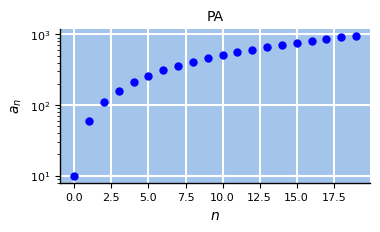

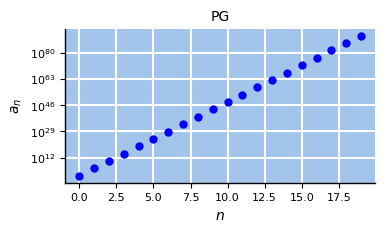

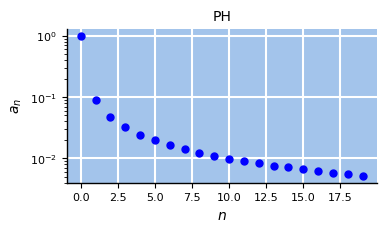

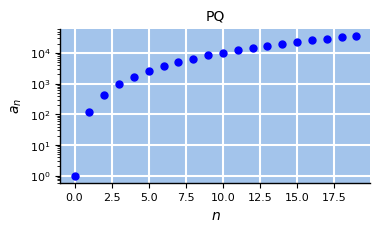

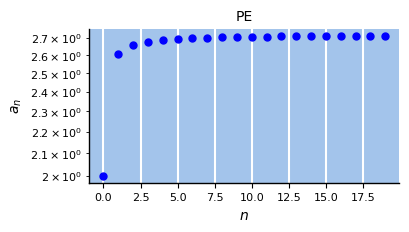

In [8]:
import matplotlib.pyplot as plt

def plot_seq(seqs: dict, lei: str, step=1):    
    
    _, ax = plt.subplots(figsize=(4, 2))
    y = seqs[lei][::step]   
    ax.semilogy(y, marker='o', ms=5, ls='', color='blue', label=lei)
    ax.set_xlabel('$n$')
    ax.set_ylabel('$a_n$')
    ax.set_title(lei, fontsize=10)
    ax.grid('both')  
    
    
for lei in seqs.keys():
    plot_seq(seqs, lei, step=10)

## Recursão

A _recursão_ é um artifício para descrever objetos em função de si mesmo, quando é complicado defini-lo de maneira explícita. Com a recursão, podemos definir conjuntos, funções e também sequências. Vimos anteriormente que a sequência de potências de 2 pode ser dada por $a_n = 2^n$. Entretanto, outra forma de defini-la é fornecendo o primeiro termo da sequência, $a_0 = 1$, e definir uma regra para encontrar o próximo termo a partir do anterior. Essa mesma sequência pode também ser dada por:

$$a_{n+1} = 2a_n; \ \ \text{com} \ \ a_0 = 1, \forall n > 1.$$

A _recursividade_, também chamada de _definição indutiva_, tem aplicação em demonstrações formais de resultados e em análise de algoritmos. Abaixo, temos exemplos de funções e sequências definidas recursivamente:

- _fatorial_: 

$$n! = 
\begin{cases} 
1, & \text{se } n = 0 \\ 
n (n-1)!, & \text{se } n > 0
\end{cases}
$$


In [9]:
# Teste da função fatorial por recursão
def fatorial(n):
    if n == 0:
        return 1  
    return n * fatorial(n - 1)

for i in range(6):
    print(f"fatorial({i}) = {fatorial(i)}")

fatorial(0) = 1
fatorial(1) = 1
fatorial(2) = 2
fatorial(3) = 6
fatorial(4) = 24
fatorial(5) = 120


- [_função de Ackerman_](https://en.wikipedia.org/wiki/Ackermann_function): 

$$A(m,n) = 
\begin{cases} 
n+1, & \text{se } m = 0 \\ 
A(m-1,1), & \text{se } m > 0 \wedge n = 0 \\
A(m-1,A(m,n-1)), & \text{se } m > 0 \wedge n > 0
\end{cases}
$$

In [10]:
def ackermann(m, n):
    if m == 0:
        return n + 1
    elif m > 0 and n == 0:
        return ackermann(m - 1, 1)
    else:
        return ackermann(m - 1, ackermann(m, n - 1))
    
for m in range(3):
    for n in range(3):
        print(f"A({m}, {n}) = {ackermann(m, n)}")    

A(0, 0) = 1
A(0, 1) = 2
A(0, 2) = 3
A(1, 0) = 2
A(1, 1) = 3
A(1, 2) = 4
A(2, 0) = 3
A(2, 1) = 5
A(2, 2) = 7


- [sequência de Josefo](https://people.math.ethz.ch/~halorenz/publications/pdf/jos.pdf): 

$$J(n,k) = 
\begin{cases} 
0, & \text{se } n = 1 \wedge k \ge 1 \\ 
(J(n-1,k) + k) \mod n, & \text{se } n > 1 \wedge k \ge 1 \\
\end{cases},
$$

onde $\mod n$ significa o resto da divisão da expressão anterior por $n$.

In [11]:
def josephus(n, k):
    if n == 1:
        return 0
    return (josephus(n - 1, k) + k) % n

for n in range(1,4):
    for k in range(1,4):    
        print(f"Josephus({n}, {k}) = {josephus(n, k)}")

Josephus(1, 1) = 0
Josephus(1, 2) = 0
Josephus(1, 3) = 0
Josephus(2, 1) = 1
Josephus(2, 2) = 0
Josephus(2, 3) = 1
Josephus(3, 1) = 2
Josephus(3, 2) = 2
Josephus(3, 3) = 1


## Relações de recorrência

A recursão ajuda-nos a especificar os termos subsequêntes de uma sequência a partir de uma ou mais _condições iniciais_. Uma _relação de recorrência_ (RR) para uma sequência $\{a_n\}$ é uma equação que expressa o termo geral $a_n$ em função de um ou mais termos prévios da sequência, isto é, para todos os números inteiros $n \ge n_0$, em que $n_0$ é um inteiro não negativo. Uma sequência é chamada _solução_ de uma RR se seus termos satisfizerem a RR. 

Nesta aula, daremos apenas alguns exemplos simples de RRs.

- $a_n = 2a_{n-1} - a_{n-2}; a_0 = 1; a_1 = 2$ (RR de 2a. ordem)

In [12]:
def rr_1(n_max):
    """
    Calcula a sequência a_n = 2*a_{n-1} - a_{n-2}
    Com condições iniciais a_0 = 1 e a_1 = 2.
    """
    
    seq = [1, 2] # a_0 e a_1
    
    if n_max == 0: return [1]
    if n_max == 1: return seq

    for _ in range(2, n_max + 1):        
        next = 2 * seq[-1] - seq[-2]
        seq.append(next)
    
    return seq

# RR é de 2a. ordem, mas resultado de crescimento linear
for n in range(10):
    print(f"RR1(n={n}): {rr_1(n)}")

RR1(n=0): [1]
RR1(n=1): [1, 2]
RR1(n=2): [1, 2, 3]
RR1(n=3): [1, 2, 3, 4]
RR1(n=4): [1, 2, 3, 4, 5]
RR1(n=5): [1, 2, 3, 4, 5, 6]
RR1(n=6): [1, 2, 3, 4, 5, 6, 7]
RR1(n=7): [1, 2, 3, 4, 5, 6, 7, 8]
RR1(n=8): [1, 2, 3, 4, 5, 6, 7, 8, 9]
RR1(n=9): [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]


- $P_n = P_{n-1} + 0.11P_{n-1}; P_0 = 10000$ (RR de 1a. ordem, equivalente à fórmula de juros compostos)

In [13]:
def rr_2(n_max,t):
    """
    Calcula o montante acumulado de um investimento com juros compostos a taxa t
    """
    
    M = [10000] # a_0 e a_1
        
    if n_max == 0: return M

    for _ in range(1, n_max + 1):        
        next = M[-1] * (1 + t)
        M.append(next)
    
    return M


for n_max in range(3):
    for t in [0.05, 0.1]:
        print(f"RR2(n_max={n_max}, t={t}): {rr_2(n_max, t)}")

RR2(n_max=0, t=0.05): [10000]
RR2(n_max=0, t=0.1): [10000]
RR2(n_max=1, t=0.05): [10000, 10500.0]
RR2(n_max=1, t=0.1): [10000, 11000.0]
RR2(n_max=2, t=0.05): [10000, 10500.0, 11025.0]
RR2(n_max=2, t=0.1): [10000, 11000.0, 12100.000000000002]


## Expresssões geradores

**Nota:** esta seção é exclusivamente computacional e atinente a Python. 

Em Python, `yield` é uma _keyword_ usada para criar geradores, tipos especiais de iteradores chamados de "preguiçosos" que permitem que valores sejam produzidos por vez, em vez de em uma batelada só, dando nascimento ao conceito de _Avaliação Preguiçosa_ (_Lazy Evaluation_). 

Antes de entrar no `yield` propriamente dito, vejamos um pouco sobre _expressões geradoras_. Por exemplo:

In [14]:
lista = [x for x in range(10)]
print(lista)

gerador = (x for x in range(10))
print(gerador)

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
<generator object <genexpr> at 0x1194e6140>


A segunda "lista" acima é uma expressão geradora, que são versões "preguiçosas" das compreensões de lista. Ela retorna um objeto "gerador". Podemos solicitar os valores da lista um por vez com `next`, ou usando `for`:

In [15]:
print(next(gerador)) # 0
print(next(gerador)) # 1
print(next(gerador)) # 2

# inicia de onde parou
for i in gerador:
    print(i)

0
1
2
3
4
5
6
7
8
9


A coisa fica mais interessante quando queremos esse comportamento em funções. Imagine a seguinte ilustração: você assa pães em sua padaria. Se um cliente lhe pedir 100 pães, você pode:

- assar os 100 pães e colocar todos em uma caixa gigante e entregar tudo de uma vez.
- assar apenas 1 pão, entregar ao cliente e simplesmente ficar parado esperando ele pedir outro. Quando o cliente lhe pedir o próximo, você assa mais um e entrega. E assim por diante. Em vez de uma caixa gigante, o espaço vai sendo preenchido um pão por vez.

Ao escrever uma função, o primeiro comportamento é o que obteríamos com `return`. O segundo, com um mecanismo especial: `yield`. A principal diferença entre os dois comandos está no que acontece com a função após a execução:

| Característica | `return` | `yield` |
| --- | --- | --- |
| **Estado** | Destrói todas as variáveis locais e encerra a função. | Congela a função e preserva o valor de todas as variáveis. |
| **Resultado** | Entrega um objeto pronto (como uma lista ou número). | Entrega um **generator** (um objeto que sabe gerar valores). |
| **Memória** | Alta (precisa guardar tudo o que será retornado). | Mínima (só guarda o que está sendo entregue no momento). |


## Funcionamento do `yield`

Quando o Python encontra o `yield`, ele não "termina" a função. Ele a transforma em um gerador. A função "anota" em qual linha parou e quais eram os valores das variáveis naquele instante.

In [16]:
def count_paes():
    print("Inicia a produção de pães...")
    yield 1
    print("Retomando de onde parou...")
    yield 2
    print("Finaliza")
    yield 3

# Objeto gerador (nada é impresso)
gerador = count_paes()

print(next(gerador)) 
print(next(gerador))
print(next(gerador))


Inicia a produção de pães...
1
Retomando de onde parou...
2
Finaliza
3


### Importância para sequências

Ao lidar com sequências grandes ou bases de dados gigantescas, o custo de memória com `yield` será sempre o mesmo, seja para 10 números ou para o "infinito". Ao gerarmos uma lista de 1 bilhão de números com `return`, o computador trabalhará pesado e pode ficar sem memória RAM. Com _lazy evaluation_, só haverá necessidade de memória se houver demanda de processamento para cálculos. Por exemplo, tomemos a sequência de quadrados.

In [17]:
# modo ansioso: muita memória
def lista_quadrados(n):
    resultado = []
    for i in range(n):
        resultado.append(i ** 2)
    return resultado

# modo preguiçoso
def gerador_quadrados(n):
    for i in range(n):
        yield i ** 2


lista = lista_quadrados(20)
print(lista)

lista_g = gerador_quadrados(100)

for _ in range(5):
    print(next(lista_g))

[0, 1, 4, 9, 16, 25, 36, 49, 64, 81, 100, 121, 144, 169, 196, 225, 256, 289, 324, 361]
0
1
4
9
16


Agora, vejamos um exemplo de `yield` aplicado à [sequência de Collatz](https://en.wikipedia.org/wiki/Collatz_conjecture):

$$a_i = 
\begin{cases} 
n, & i = 0\\ 
f(a_{i-1}), & i > 0
\end{cases},
$$

para a função

$$f(n) = 
\begin{cases} 
n/2, & \text{se } n \text{ par}\\ 
3n + 1, & \text{se } n \text{ ímpar}
\end{cases},
$$

$a_i$ é o valor de $f$ aplicada a $n$ recursivamente $i$ vezes. Isto é, $a_i = f^i(n)$.

In [18]:
def collatz(n):
    while n != 1:        
        yield n         
        n = n // 2 if n % 2 == 0 else 3 * n + 1
    yield 1
    
for i in range(1, 11):
    print(f"Collatz({i}): {list(collatz(i))}")

Collatz(1): [1]
Collatz(2): [2, 1]
Collatz(3): [3, 10, 5, 16, 8, 4, 2, 1]
Collatz(4): [4, 2, 1]
Collatz(5): [5, 16, 8, 4, 2, 1]
Collatz(6): [6, 3, 10, 5, 16, 8, 4, 2, 1]
Collatz(7): [7, 22, 11, 34, 17, 52, 26, 13, 40, 20, 10, 5, 16, 8, 4, 2, 1]
Collatz(8): [8, 4, 2, 1]
Collatz(9): [9, 28, 14, 7, 22, 11, 34, 17, 52, 26, 13, 40, 20, 10, 5, 16, 8, 4, 2, 1]
Collatz(10): [10, 5, 16, 8, 4, 2, 1]


Este código faz o seguinte:

- `def collatz(n)`: Inicia a função recebendo o número inicial `n`.
- `while n != 1`: não importa o número inicial positivo, a sequência sempre terminará em 1. O loop continua até chegar lá.
- `yield n`: a função pausa e "cospe" o número atual da sequência.
- `n = n // 2 if n % 2 == 0 else 3 * n + 1` Esta é a regra de transição escrita em uma única linha (operador ternário). Quando a função "despausar", ela calcula o próximo número:
- `if n % 2 == 0`, o novo `n` será a metade (`n // 2`).
- `else`, o novo n será multiplicado por 3 e somado a `(3 * n + 1)`.
- `yield 1`: quando o `while` termina (ou seja, `n` virou `1`), ele entrega o número final da sequência.

In [19]:
plt.rcdefaults()

## Exercícios aplicados resolvidos

**I.** Na economia e em finanças pessoais, um dos conceitos mais poderosos é o dos juros compostos associados a aportes regulares. Imagine que um investidor decide criar um fundo de aposentadoria. Ele não apenas deixa um dinheiro inicial rendendo, mas também adiciona uma quantia fixa todos os meses. 

A investidora Helena abriu uma conta de investimentos com um depósito inicial de $R\$$ 5.000,00. O fundo de investimento oferece uma taxa de juros fixa de $0,8\%$ ao mês (ou seja, a taxa $r = 0,008$). Além disso, no último dia de cada mês, Helena deposita mais $R\$$$ 800,00 na conta.

O saldo da conta no mês $n$ pode ser modelado por uma sequência matemática recursiva:

* _caso-base_ ($n = 0$): $S_0 = 5000$ (Saldo inicial)
* _passo recursivo_ ($n > 0$): $S_n = S_{n-1} \times (1 + r) + D$, onde $S_n$ é o saldo no mês atual, $S_{n-1}$ é o saldo do mês anterior, $r$ é a taxa de juros e $D$ é o depósito mensal.

Escreva um script que utilize uma função recursiva para calcular qual será o patrimônio exato de Helena: 

- após 12 meses (1 ano);
- após 120 meses (10 anos).

In [20]:
def calcular_patrimonio(meses, saldo_inicial, taxa_juros, deposito_mensal):
    """Calcula o saldo de um investimento recursivamente."""
    
    # Caso base
    if meses == 0:
        return saldo_inicial
    
    # Passo recursivo
    saldo_mes_anterior = calcular_patrimonio(meses - 1, saldo_inicial, taxa_juros, deposito_mensal)
    
    # Aplica os juros sobre o saldo anterior e soma o novo aporte
    saldo_atual = (saldo_mes_anterior * (1 + taxa_juros)) + deposito_mensal
    
    return saldo_atual

# Parâmetros do Problema
capital_inicial = 5000.00
taxa_mensal = 0.008      # 0,8% de rendimento ao mês
aporte = 800.00

# Patrimônio após 1 ano (12 meses)
meses_cenario_1 = 12
resultado_1 = calcular_patrimonio(meses_cenario_1, capital_inicial, taxa_mensal, aporte)

# Patrimônio após 10 anos (120 meses)
meses_cenario_2 = 120
resultado_2 = calcular_patrimonio(meses_cenario_2, capital_inicial, taxa_mensal, aporte)

# --- Exibindo os resultados ---
print("=== Simulador de Investimentos de Helena ===")
print(f"Saldo inicial: R$ {capital_inicial:.2f}")
print(f"Aporte mensal: R$ {aporte:.2f}")
print(f"Taxa de juros: {taxa_mensal*100:.1f}% ao mês\n")

print(f"-> Patrimônio acumulado após {meses_cenario_1} meses: R$ {resultado_1:.2f}")
print(f"-> Patrimônio acumulado após {meses_cenario_2} meses: R$ {resultado_2:.2f}")


=== Simulador de Investimentos de Helena ===
Saldo inicial: R$ 5000.00
Aporte mensal: R$ 800.00
Taxa de juros: 0.8% ao mês

-> Patrimônio acumulado após 12 meses: R$ 15535.56
-> Patrimônio acumulado após 120 meses: R$ 173182.67
